# 06: rank と精度のトレードオフを調べる

## 一言で言うと
学習済み MLP の `fc1` / `fc2` を **いろいろな rank** で SVD 圧縮し、  
**精度・パラメータ数・計算量・推論時間・予測の近さ** の関係を表とグラフで見るノート。

## 流れ

```text
学習（baseline model）
  ↓
(r1, r2) の組み合わせで 2層SVD圧縮
  ↓
Acc / params / MACs / 時間 / agreement / logits RMSE / retained energy
  ↓
表・ヒートマップ・散布図でトレードオフを可視化
```

## セルの役割

| あたり | 何をしているか |
|--------|----------------|
| import〜学習ループ | ベースライン MLP を学習 |
| SVD / Rebuild / devidetwolayer | 低ランク近似と 2層化 |
| 評価関数群 | Acc差・params・MACs・速度・一致率など |
| rank sweep | `(r1, r2)` 全組み合わせを走査して `results` を作る |
| DataFrame・グラフ | トレードオフを可視化して保存 |

## 用語
- **rank r**: 残す特異値の個数（小さいほど圧縮↑・精度↓しやすい）
- **retained_energy**: 残した特異値が元のエネルギーの何割か（1に近いほど近似が良い）
- **agreement**: 正解ラベルではなく、**ベースラインと同じ予測をした割合**
- **logits_rmse**: 圧縮前後の出力スコアのずれ（RMSE）
- **compression_ratio / MACs**: パラメータ圧縮倍率と計算量の目安


In [2]:
# ============================================================
# ライブラリの import
# ============================================================
import torch
import torch.nn as nn          # 層の定義（Linear, ReLU など）
import torch.optim as optim    # 最適化（Adam など）

from torch.utils.data import DataLoader          # ミニバッチでデータを流す
from torchvision import datasets, transforms     # MNIST と前処理

In [3]:
# ============================================================
# デバイス選択（GPU があれば cuda、なければ cpu）
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
# 今の環境は CPU でも MNIST MLP なら数分で学習できる

device: cuda


In [4]:
# ============================================================
# MNIST データの準備
# ============================================================
# ToTensor(): 画像を [0,1] の float テンソルに変換
#   元: PIL Image (28×28) → 後: Tensor (1, 28, 28)
transform = transforms.Compose([
    transforms.ToTensor()
])

# root="./data" にダウンロード＆キャッシュされる
# 初回だけダウンロード。LeCun サイトが 404 でもミラーから取れるので正常
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# DataLoader: データをミニバッチに分割して渡す
train_loader = DataLoader(
    train_dataset,
    batch_size=64,   # 1回の更新で使う枚数
    shuffle=True     # 学習時は順番を混ぜる
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False    # 評価時は混ぜなくてよい
)

print("train size:", len(train_dataset))  # 60000（規定値）
print("test size:", len(test_dataset))    # 10000（規定値）

100.0%
100.0%
100.0%
100.0%

train size: 60000
test size: 10000


In [5]:
# ============================================================
# 1バッチだけ取り出して shape を確認
# ============================================================
images, labels = next(iter(train_loader))

print("images shape:", images.shape)  # (64, 1, 28, 28) = バッチ, チャネル, H, W
print("labels shape:", labels.shape)  # (64,)
print("labels:", labels[:10])         # 0〜9 のクラスラベル

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])
labels: tensor([7, 9, 2, 0, 4, 5, 9, 2, 0, 6])


In [6]:
# ============================================================
# MLP の定義
# ============================================================
# ポイント:
#   - forward の仕事は「画像 → 10クラスのスコア」まで通すこと
#   - SVD は forward の途中で毎回やらなくてよい（あとで重みに対して1回やる）
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()

        # まずは普通の MLP（04と同じ構造）で学習する
        self.fc1 = nn.Linear(784, 512,bias=True)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(512, 256,bias=True)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 10,bias=True)

    def forward(self, x):
        # x: (batch, 1, 28, 28) → (batch, 784)
        x = x.view(x.size(0), -1)
        x = self.relu1(self.fc1(x))  # (batch, 512)
        x = self.relu2(self.fc2(x))  # (batch, 256)
        x = self.fc3(x)              # (batch, 10) ← CrossEntropy に渡す形

        return x

In [7]:
# ============================================================
# モデル・損失関数・最適化手法の準備
# ============================================================

# MNISTMLP() で、さっき定義したニューラルネット本体を作っています。
# .to(device) は、そのモデルをGPU に移しています。
model = MNISTMLP().to(device)

# 多クラス分類なので CrossEntropyLoss
# （内部で log_softmax + NLLLoss をやるので、モデル出力は logits のまま）
criterion = nn.CrossEntropyLoss()

# Adam: 学習率 0.001 はよく使う初期値
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

MNISTMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


In [8]:
# ============================================================
# 学習 1 epoch = 「全データを1回見て、間違いを直す」
# ============================================================
# 1バッチごとのやること（これが学習の本体）:
#   1. 画像を入れる → 予測が出る
#   2. 正解と比べて loss（間違い）を計算
#   3. 「どの重みをどう直せばいいか」を計算（backward）
#   4. 重みを少し更新（step）
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    # model.train() は nn.Module が持っている仕組み
    # モデル自身とその子モジュールの training 状態を True にします
    # 今はなくてもあっても変わらない
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:  # 64枚ずつ取り出す
        images = images.to(device)
        labels = labels.to(device)

        # PyTorch は勾配を足し込むので、毎回リセット
        optimizer.zero_grad()            # ① 前回の修正メモを消す

        # forwardを使って計算している
        # outputs = model.forward(images)と同じ
        outputs = model(images)          # ② 予測（10クラス分のスコア）

        loss = criterion(outputs, labels)  # ③ 間違いの大きさ

        # 誤差逆伝播をして勾配を作る
        # forwardで計算したlossをbackwardで勾配を計算する
        loss.backward()                  # ④ どこを直せばいいか計算

        # backwardで計算した勾配をstepで更新する
        # 各層のパラメータを更新
        optimizer.step()                 # ⑤ 重みを少し直す

        # loss.item() はそのバッチの平均損失
        # images.size(0) を掛けるのは、64枚分の損失の合計っぽいものに直して、
        # あとで全体平均を取るため
        total_loss += loss.item() * images.size(0)

        # 0~9での各スコアを比較して１番大きいものをとる→これが予測
        predicted = torch.argmax(outputs, dim=1)  # 一番高いスコアの数字

        # 予測と正解を比較して、正解している数を数える
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total   # 平均 loss
    accuracy = correct / total      # 正解率

    return avg_loss, accuracy

In [9]:
# ============================================================
# テストデータでの評価（学習はしない）
# ============================================================
def evaluate(model, test_loader, criterion, device):
    model.eval()  # 評価モード

    total_loss = 0.0
    correct = 0
    total = 0

    # 評価時は勾配不要 → メモリ節約・高速化
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

In [10]:
# ============================================================
# 学習ループ（5 epoch）
# ============================================================
# 目安: Test Acc が 97〜98% くらいまで上がれば OK
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device)

    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Test Loss: {test_loss:.4f}, "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch [1/5] Train Loss: 0.2351, Train Acc: 0.9294, Test Loss: 0.1018, Test Acc: 0.9692
Epoch [2/5] Train Loss: 0.0872, Train Acc: 0.9727, Test Loss: 0.0897, Test Acc: 0.9728
Epoch [3/5] Train Loss: 0.0583, Train Acc: 0.9816, Test Loss: 0.0781, Test Acc: 0.9766
Epoch [4/5] Train Loss: 0.0402, Train Acc: 0.9872, Test Loss: 0.0751, Test Acc: 0.9773
Epoch [5/5] Train Loss: 0.0320, Train Acc: 0.9894, Test Loss: 0.0688, Test Acc: 0.9812


In [11]:
# ============================================================
# SVD（学習の外で、重み行列 W を分解する）
# ============================================================
# W ≈ U_r @ diag(S_r) @ Vh_r
#   U_r : 左特異ベクトル（out × r）
#   S_r : 特異値（r,）← 対角行列の対角成分だけ
#   Vh_r: 右特異ベクトル（r × in）
def SVD(W, r):
    """重み行列 W を rank r で打ち切った SVD を返す"""
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    U_r = U[:, :r]   # 上位 r 列だけ残す
    S_r = S[:r]      # 上位 r 個の特異値
    Vh_r = Vh[:r, :] # 上位 r 行だけ残す

    return U_r, S_r, Vh_r

In [12]:
# ============================================================
# SVDで分解したものを再構築する
# ============================================================
def RebuildSVD(U_r, S_r, Vh_r,layer):
    W_r = U_r @ torch.diag(S_r) @ Vh_r

    new_layer = nn.Linear(
    layer.in_features,
    layer.out_features,
    bias=True,)

    with torch.no_grad():
        new_layer.weight.copy_(W_r)
        new_layer.bias.copy_(layer.bias)
    
    return new_layer.to(layer.weight.device)

In [13]:
# ============================================================
# 1層を2層に分けて計算コストを削減する
# ============================================================
# 元: Linear(in → out)
# 後: Linear(in → r, bias=False) + Linear(r → out, bias=True)
#
# 対応:
#   first.weight  = Vh_r
#   second.weight = U_r @ diag(S_r)
#   second.bias   = 元の bias
def devidetwolayer(layer,r):
    # 中間次元と低ランク数はいっしょにすべき？
    # → ここでは中間次元 = rank r として分解している
    U_r, S_r, Vh_r = SVD(layer.weight.detach(),r)  # detach: 勾配グラフから外す
    first_layer = nn.Linear(layer.in_features, r, bias=False)  # 中間次元 r、bias は不要
    second_layer = nn.Linear(r, layer.out_features, bias=True)  # 最終出力、bias はここに置く
    with torch.no_grad():  # 重みの代入時は勾配を計算しない
        first_layer.weight.copy_(Vh_r)                  # (r, in)
        second_layer.weight.copy_(U_r @ torch.diag(S_r))  # (out, r)
        second_layer.bias.copy_ (layer.bias.data)      # 元の bias をそのまま
    # 新規 Linear は CPU 上で作られるので、元の層と同じ device へ移す
    # 元の layer.weight がいる device を見て、新しく作った first_layer と second_layer を
    # 同じ場所に移してから返す、
    return nn.Sequential(first_layer,second_layer).to(layer.weight.device)


In [14]:
# ============================================================
# 2層に分解しせず、SVDを適用したモデルで評価
# ============================================================
# one_layer_svd_mode の骨格だけ作り、各 fc を「学習済み model の圧縮版」で差し替える

def make_one_layer_svd_model(model,r1,r2):
    one_layer_svd_model = MNISTMLP().to(device)
    # *は関数の結果を分解して渡す
    one_layer_svd_model.fc1 = RebuildSVD(*SVD(model.fc1.weight.detach(),r1),model.fc1)
    # fc2: 512→256
    one_layer_svd_model.fc2 = RebuildSVD(*SVD(model.fc2.weight.detach(),r2),model.fc2)
    # fc3: 256→10（もともと小さい層）
    #one_layer_svd_mode.fc3 = RebuildSVD(*SVD(model.fc3.weight.detach(),r3),model.fc3)
    one_layer_svd_model.fc3 =model.fc3

    return one_layer_svd_model

In [15]:
# ============================================================
# 2層に分解し、SVDを適用したモデルで評価
# ============================================================
# two_layer_svd_model の骨格だけ作り、各 fc を「学習済み model の圧縮版」で差し替える

def make_two_layer_svd_model(model,r1,r2):
    two_layer_svd_model = MNISTMLP().to(device)
    # modelに近似したものを入れる（rank が小さいほど圧縮↑）
    two_layer_svd_model.fc1 = devidetwolayer(model.fc1,r1)
    two_layer_svd_model.fc2 = devidetwolayer(model.fc2,r2)
    #two_layer_svd_model.fc3 = devidetwolayer(model.fc3,r3)
    two_layer_svd_model.fc3 = model.fc3

    return two_layer_svd_model

In [16]:
# ============================================================
# パラメータ数を数える（圧縮後と比較する基準）
# ============================================================
# fc1: 784*512+512 = 401,920
# fc2: 512*256+256 = 131,328
# fc3: 256*10+10   =   2,570
# 合計             = 535,818
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def compare_parameters(model,comparison_model):
    baseline_params = count_parameters(model)       # 圧縮前
    new_params=count_parameters(comparison_model)      # 圧縮後
    print("Baseline params:", baseline_params)
    print("New params:", new_params)

    # compression_ratio = 元 / 圧縮後 → 大きいほど圧縮できている
    compression_ratio = baseline_params / new_params
    # 何割減ったか（例: 0.75 = 75%削減）
    parameter_reduction_rate = 1.0 - new_params / baseline_params
    print(f"Compression ratio: {compression_ratio:.2f}倍")
    print(f"Parameter reduction: {parameter_reduction_rate:.2%}")


In [17]:
# ============================================================
# 精度の低下量（圧縮のトレードオフ）
# ============================================================
# test_acc     : 圧縮前（学習直後）
# new_test_acc : 圧縮後

def accuracy_drop(test_acc, new_test_acc, verbose=True):
    drop = test_acc - new_test_acc
    if verbose:
        print("Baseline accuracy:", test_acc)
        print("Compressed accuracy:", new_test_acc)
        # drop は float なので、Python 標準の round を使う
        # （torch.round は Tensor 用）
        print("Accuracy drop:", round(drop, 5))
    return drop  # results やグラフ用に数値を返す

In [18]:
# ============================================================
# MACs(Multiply-Accumulate Operations（乗算加算演算)
# ============================================================
# 1サンプルあたりの計算量の理論値
# Linear(in→out) ≈ in * out
# 圧縮後2層 ≈ in*r + r*out
def linear_macs(layer):
    #Linear層の1サンプル当たりのMACs
    return layer.in_features * layer.out_features

def compressed_linear_macs(in_features, out_features, rank):
    #SVD後の2層LinearのMACs
    return in_features * rank + rank * out_features

def MACs(model, r1, r2, verbose=True):
    baseline_macs = (
        linear_macs(model.fc1)
        + linear_macs(model.fc2)
        + linear_macs(model.fc3)
    )

    compressed_macs = (
        compressed_linear_macs(784, 512, r1)
        + compressed_linear_macs(512, 256, r2)
        + linear_macs(model.fc3)
    )

    # 計算量が何割減ったか
    compute_reduction_rate = 1.0 - compressed_macs / baseline_macs

    if verbose:
        print("Baseline MACs:", baseline_macs)
        print("Compressed MACs:", compressed_macs)
        print(f"Compute reduction: {compute_reduction_rate:.2%}")

    # グラフ用には compressed_macs を主に使う
    return baseline_macs, compressed_macs, compute_reduction_rate


In [19]:
# ============================================================
# 実測の推論速度比較（1バッチあたりの平均時間）
# ============================================================
import time

def benchmark_inference(model,data_loader, device, warmup=10, repeats=5000):
    """1バッチ当たりの平均推論時間を測定する。"""
    # このコードでは意味ない
    # → 小さな MLP + GPU だと差が出にくい、という意味合い
    model.eval()

    images, _ = next(iter(data_loader))
    images = images.to(device)

    # ウォームアップ（初回の遅さを測りに入れない）
    # _は捨て変数で使わないの意味
    # 何回かウォームアップするけど、値は使わないよってこと
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(images)

    # GPU は非同期なので、計時前後で同期して正確に測る
    if device.type == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()

    with torch.no_grad():
        for _ in range(repeats):
            _ = model(images)

    if device.type == "cuda":
        torch.cuda.synchronize()

    elapsed = time.perf_counter() - start

    return elapsed / repeats  # 1回あたりの秒数

def benchmark_inference_print(model, two_layer_svd_model, test_loader, device, verbose=True):
    baseline_time = benchmark_inference(model, test_loader, device)
    two_layer_svd_model_time = benchmark_inference(two_layer_svd_model, test_loader, device)

    if verbose:
        print(f"Baseline: {baseline_time * 1000:.3f} ms/batch")
        print(f"TwolayerSVD: {two_layer_svd_model_time * 1000:.3f} ms/batch")

    # 秒 → あとで DataFrame では ms にしてもよい
    return baseline_time, two_layer_svd_model_time


In [20]:
# ============================================================
# 予測一致率 agreement
# ============================================================
# 正解ラベルとの一致（accuracy）ではなく、
# 「圧縮前モデルと同じクラスを予測した割合」を測る。
# Acc が同程度でも、別の間違い方をしていないかのチェック用。
def agreement(baseline, compressed, loader, device):
    baseline.eval()
    compressed.eval()

    agreement_count = 0
    total = 0

    # inference_mode: 勾配不要・推論専用（no_grad より少し軽い）
    with torch.inference_mode():
        # ラベルは使わないので _ で捨てる
        for images, _ in loader:
            images = images.to(device)

            # 各サンプルの予測クラス（スコア最大の次元）
            baseline_pred = baseline(images).argmax(dim=1)
            compressed_pred = compressed(images).argmax(dim=1)

            agreement_count += (
                baseline_pred == compressed_pred
            ).sum().item()
            total += images.size(0)

    return agreement_count / total  # 0〜1（1 = 完全に同じ予測）


In [21]:
# ============================================================
# logits の RMSE（出力スコアのずれ）
# ============================================================
# agreement は「最終予測クラス」だけ見るのに対し、
# こちらは 10 クラス分の生スコア（logits）全体のずれを測る。
# 予測クラスが同じでも、確信度の差が大きいと RMSE は上がる。
def logits_rmse(baseline, compressed, loader, device):
    baseline.eval()
    compressed.eval()

    squared_error_sum = 0.0
    element_count = 0

    with torch.inference_mode():
        for images, _ in loader:
            images = images.to(device)

            # argmax せず、全クラスの logits を比較する
            baseline_logits = baseline(images)       # (batch, 10)
            compressed_logits = compressed(images)   # (batch, 10)

            difference = baseline_logits - compressed_logits
            squared_error_sum += difference.square().sum().item()
            element_count += difference.numel()

    # √(平均二乗誤差) → 要素あたりの典型的なズレ
    return (squared_error_sum / element_count) ** 0.5


In [22]:
# ============================================================
# 特異値エネルギーの保持率 retained_energy
# ============================================================
# Frobenius ノルムの二乗 = 特異値の二乗和、なので
#   sum(S[:r]^2) / sum(S^2)
# は「rank r で重みのエネルギーの何割を残したか」になる。
# 1 に近いほど近似が良く、精度低下も抑えやすい目安。
def retained_energy(layer, rank):
    singular_values = torch.linalg.svdvals(
        layer.weight.detach()
    )

    return (
        singular_values[:rank].square().sum()
        / singular_values.square().sum()
    ).item()


In [23]:
# ============================================================
# rank を変えて精度・params・MACs・近さ指標を集める
# ============================================================
import itertools

r1_list = [16, 32, 64, 128]  # fc1 の候補
r2_list = [16, 32, 64, 128]  # fc2 の候補
rank_configs = list(itertools.product(r1_list, r2_list))

# ベースライン推論時間は1回だけ測る（ループ内で毎回やらない）
baseline_time_s = benchmark_inference(
    model, test_loader, device, warmup=20, repeats=2000
)

results = []

for fc1_rank, fc2_rank in rank_configs:
    two_layer_svd_model = make_two_layer_svd_model(
        model,
        r1=fc1_rank,
        r2=fc2_rank,
    )

    two_layer_test_loss, two_layer_test_accuracy = evaluate(
        two_layer_svd_model,
        test_loader,
        criterion,
        device,
    )

    # verbose=False で print を抑え、戻り値だけ使う
    drop = accuracy_drop(test_acc, two_layer_test_accuracy, verbose=False)
    # _ は「ここに何か来るけど、今回は使わない」という意味の捨て変数
    _, compressed_macs, compute_reduction = MACs(
        model, fc1_rank, fc2_rank, verbose=False
    )
    compressed_time_s = benchmark_inference(
        two_layer_svd_model, test_loader, device, warmup=5, repeats=200
    )
    retained_energy_fc1 = retained_energy(model.fc1, fc1_rank)
    retained_energy_fc2 = retained_energy(model.fc2, fc2_rank)

    row = {
        "fc1_rank": fc1_rank,
        "fc2_rank": fc2_rank,
        "parameters": count_parameters(two_layer_svd_model),
        
        "test_loss": two_layer_test_loss,
        "test_accuracy": two_layer_test_accuracy,
        "accuracy_drop": drop,
        "compressed_macs": compressed_macs,
        "compute_reduction": compute_reduction,
        "baseline_time_ms": baseline_time_s * 1000,
        "compressed_time_ms": compressed_time_s * 1000,
        # 近さ指標: 予測一致率 / logits ずれ / 特異値エネルギー保持率
        "agreement": agreement(model, two_layer_svd_model, test_loader, device),
        "logits_rmse": logits_rmse(model, two_layer_svd_model, test_loader, device),
        "retained_energy_fc1": retained_energy_fc1,
        "retained_energy_fc2": retained_energy_fc2,

    }
    results.append(row)

    # 進行状況は1行だけ
    print(
        f"r1={fc1_rank:3d}, r2={fc2_rank:3d} | "
        f"Acc={two_layer_test_accuracy:.4f} "
        f"(drop={drop:+.4f}) | "
        f"params={row['parameters']} | "
        f"MACs={compressed_macs}|"
        f"time={compressed_time_s*1000:.3f}ms|"
        f"agreement={row['agreement']:.4f}"
    )

print(f"\n集計完了: {len(results)} 件")


r1= 16, r2= 16 | Acc=0.8653 (drop=+0.1159) | params=36362 | MACs=35584|time=0.167ms|agreement=0.8682
r1= 16, r2= 32 | Acc=0.8615 (drop=+0.1197) | params=48650 | MACs=47872|time=0.139ms|agreement=0.8642
r1= 16, r2= 64 | Acc=0.8603 (drop=+0.1209) | params=73226 | MACs=72448|time=0.164ms|agreement=0.8631
r1= 16, r2=128 | Acc=0.8596 (drop=+0.1216) | params=122378 | MACs=121600|time=0.179ms|agreement=0.8624
r1= 32, r2= 16 | Acc=0.9762 (drop=+0.0050) | params=57098 | MACs=56320|time=0.122ms|agreement=0.9841
r1= 32, r2= 32 | Acc=0.9770 (drop=+0.0042) | params=69386 | MACs=68608|time=0.140ms|agreement=0.9851
r1= 32, r2= 64 | Acc=0.9770 (drop=+0.0042) | params=93962 | MACs=93184|time=0.149ms|agreement=0.9852
r1= 32, r2=128 | Acc=0.9777 (drop=+0.0035) | params=143114 | MACs=142336|time=0.148ms|agreement=0.9853
r1= 64, r2= 16 | Acc=0.9800 (drop=+0.0012) | params=98570 | MACs=97792|time=0.145ms|agreement=0.9938
r1= 64, r2= 32 | Acc=0.9804 (drop=+0.0008) | params=110858 | MACs=110080|time=0.135ms|a

In [24]:
# ============================================================
# results を表にして見やすくする（グラフ用の土台）
# ============================================================
import pandas as pd

# list[dict] → DataFrame（この形がグラフ・集計に一番使いやすい）
df_results = pd.DataFrame(results)

# 見やすい表示用に丸める（元の df_results は生の数値のまま残す）
df_view = df_results.copy()
df_view["test_loss"] = df_view["test_loss"].round(4)
df_view["test_accuracy"] = df_view["test_accuracy"].round(4)
df_view["accuracy_drop"] = df_view["accuracy_drop"].round(4)
df_view["compute_reduction"] = (df_view["compute_reduction"] * 100).round(2)
df_view["baseline_time_ms"] = df_view["baseline_time_ms"].round(3)
df_view["compressed_time_ms"] = df_view["compressed_time_ms"].round(3)
df_view = df_view.rename(columns={"compute_reduction": "compute_reduction_%"})
df_view["retained_energy_fc1"] = df_view["retained_energy_fc1"].round(4)
df_view["retained_energy_fc2"] = df_view["retained_energy_fc2"].round(4)
df_view["logits_rmse"] = df_view["logits_rmse"].round(4)

# Acc が高い順
df_view_sorted = df_view.sort_values("test_accuracy", ascending=False)

print("=== Acc が高い順（見やすい表） ===")
display(df_view_sorted)

print("\n生データ（グラフ用）の先頭:")
display(df_results.head())


=== Acc が高い順（見やすい表） ===


,fc1_rank,fc2_rank,parameters,test_loss,test_accuracy,accuracy_drop,compressed_macs,compute_reduction_%,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,retained_energy_fc2
14,128,64,218378,0.0687,0.9817,-0.0005,217600,59.33,0.129,0.120,0.9974,0.2554,0.8873,0.8823
15,128,128,267530,0.0687,0.9814,-0.0002,266752,50.14,0.129,0.122,0.9977,0.2151,0.8873,0.9543
13,128,32,193802,0.0693,0.9813,-0.0001,193024,63.92,0.129,0.125,0.9976,0.3539,0.8873,0.8083
12,128,16,181514,0.0741,0.9808,0.0004,180736,66.22,0.129,0.130,0.9960,0.6375,0.8873,0.7315
9,64,32,110858,0.0679,0.9804,0.0008,110080,79.43,0.129,0.135,0.9937,0.6106,0.7888,0.8083
11,64,128,184586,0.0672,0.9804,0.0008,183808,65.65,0.129,0.116,0.9940,0.5483,0.7888,0.9543
10,64,64,135434,0.0673,0.9802,0.0010,134656,74.83,0.129,0.194,0.9937,0.5609,0.7888,0.8823
8,64,16,98570,0.0724,0.9800,0.0012,97792,81.72,0.129,0.145,0.9938,0.7652,0.7888,0.7315
7,32,128,143114,0.0772,0.9777,0.0035,142336,73.40,0.129,0.148,0.9853,1.5639,0.6597,0.9543
5,32,32,69386,0.0782,0.9770,0.0042,68608,87.18,0.129,0.140,0.9851,1.5665,0.6597,0.8083



生データ（グラフ用）の先頭:


,fc1_rank,fc2_rank,parameters,test_loss,test_accuracy,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,compressed_time_ms,agreement,logits_rmse,retained_energy_fc1,retained_energy_fc2
0,16,16,36362,0.522243,0.8653,0.1159,35584,0.933493,0.129436,0.166504,0.8682,3.690561,0.498193,0.731507
1,16,32,48650,0.536452,0.8615,0.1197,47872,0.910526,0.129436,0.138946,0.8642,3.713899,0.498193,0.808311
2,16,64,73226,0.540905,0.8603,0.1209,72448,0.864593,0.129436,0.163969,0.8631,3.724812,0.498193,0.882251
3,16,128,122378,0.545594,0.8596,0.1216,121600,0.772727,0.129436,0.179396,0.8624,3.730002,0.498193,0.954306
4,32,16,57098,0.081469,0.9762,0.0050,56320,0.894737,0.129436,0.122131,0.9841,1.559212,0.659694,0.731507


In [25]:
# ============================================================
# グラフ用にデータを加工する
# ============================================================
# よく使う形:
#   1) 長い表 df_results（そのまま scatter 向き）
#   2) ピボット表（行=fc1, 列=fc2）→ heatmap 向き

# Acc のピボット（heatmap 用）
acc_pivot = df_results.pivot(
    index="fc1_rank", columns="fc2_rank", values="test_accuracy"
)
drop_pivot = df_results.pivot(
    index="fc1_rank", columns="fc2_rank", values="accuracy_drop"
)
params_pivot = df_results.pivot(
    index="fc1_rank", columns="fc2_rank", values="parameters"
)
macs_pivot = df_results.pivot(
    index="fc1_rank", columns="fc2_rank", values="compressed_macs"
)


print("Acc pivot (heatmap 用)")
display(acc_pivot.round(4))

# fc2 を固定して fc1 だけ見る、など線グラフ用の切り出し例
# 例: fc2_rank == 64 のとき
df_fc2_64 = df_results[df_results["fc2_rank"] == 64].sort_values("fc1_rank")
df_fc2_128 = df_results[df_results["fc2_rank"] == 128].sort_values("fc1_rank")
print("\nfc2=64 のとき（線グラフ用）")
display(df_fc2_64[["fc1_rank", "test_accuracy", "parameters", "compressed_macs"]])


Acc pivot (heatmap 用)


fc2_rank,16,32,64,128
fc1_rank,,,,
16,0.8653,0.8615,0.8603,0.8596
32,0.9762,0.9770,0.9770,0.9777
64,0.9800,0.9804,0.9802,0.9804
128,0.9808,0.9813,0.9817,0.9814



fc2=64 のとき（線グラフ用）


,fc1_rank,test_accuracy,parameters,compressed_macs
2,16,0.8603,73226,72448
6,32,0.9770,93962,93184
10,64,0.9802,135434,134656
14,128,0.9817,218378,217600


    fc1_rank  retained_energy_fc1
0         16             0.498193
4         32             0.659694
8         64             0.788782
12       128             0.887327
   fc2_rank  retained_energy_fc2
0        16             0.731507
1        32             0.808311
2        64             0.882251
3       128             0.954306
saved: D:\dev\nn-compression-svd-dmrg\notebooks\10_mnist_mlp\06_mnist_rank_accuracy_tradeoff\rank_accuracy_tradeoff.png


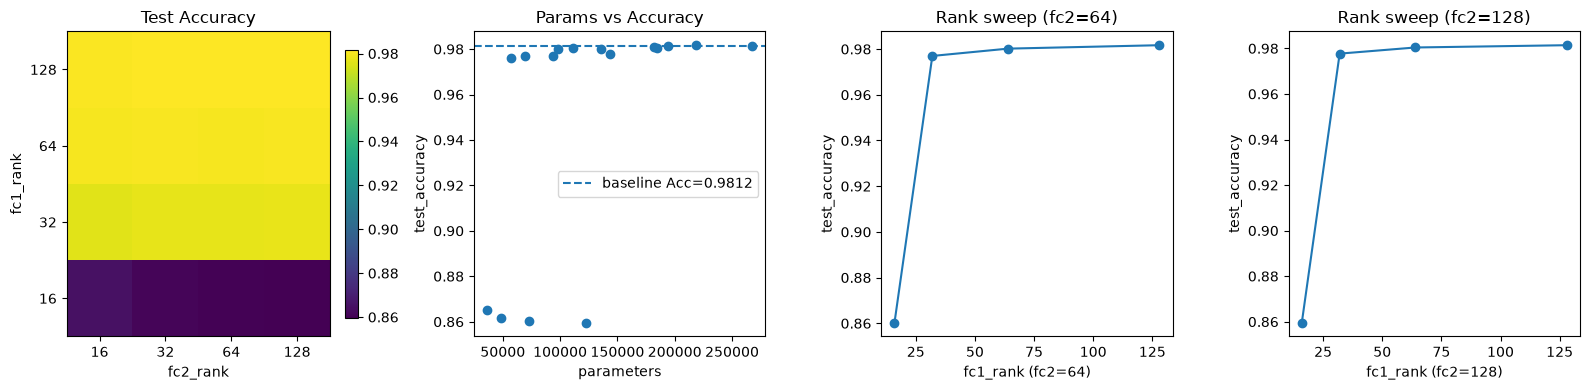

saved: D:\dev\nn-compression-svd-dmrg\notebooks\10_mnist_mlp\06_mnist_rank_accuracy_tradeoff\retained_energy.png


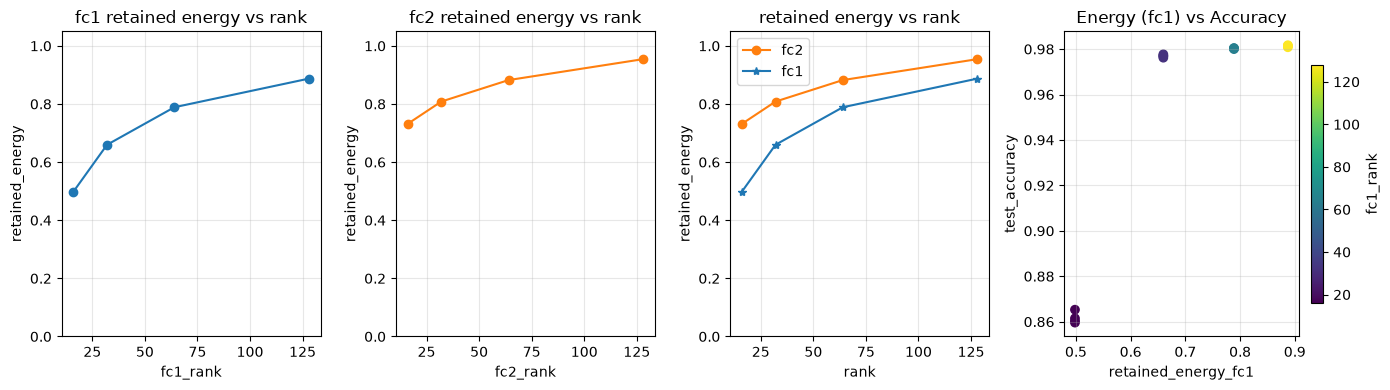

In [26]:
# ============================================================
# グラフ例（df_results があればこのセルだけで描ける）
# 画像は ./06_mnist_rank_accuracy_tradeoff/ に保存
# ============================================================
from pathlib import Path
import matplotlib.pyplot as plt

out_dir = Path("06_mnist_rank_accuracy_tradeoff")
out_dir.mkdir(parents=True, exist_ok=True)

# 必要な表をここで用意
acc_pivot = df_results.pivot(
    index="fc1_rank", columns="fc2_rank", values="test_accuracy"
)
df_fc2_64 = df_results[df_results["fc2_rank"] == 64].sort_values("fc1_rank")
df_fc2_128 = df_results[df_results["fc2_rank"] == 128].sort_values("fc1_rank")

# retained_energy は各層の rank だけで決まるので、重複を除いて線にする
df_energy_fc1 = (
    df_results[["fc1_rank", "retained_energy_fc1"]]
    .drop_duplicates("fc1_rank")
    .sort_values("fc1_rank")
)
df_energy_fc2 = (
    df_results[["fc2_rank", "retained_energy_fc2"]]
    .drop_duplicates("fc2_rank")
    .sort_values("fc2_rank")
)

print(df_energy_fc1)
print(df_energy_fc2)

# ------------------------------------------------------------
# 図1: Acc / params のトレードオフ
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

im0 = axes[0].imshow(acc_pivot.values, origin="lower", aspect="auto")
axes[0].set_xticks(range(len(acc_pivot.columns)))
axes[0].set_yticks(range(len(acc_pivot.index)))
axes[0].set_xticklabels(list(acc_pivot.columns))
axes[0].set_yticklabels(list(acc_pivot.index))
axes[0].set_xlabel("fc2_rank")
axes[0].set_ylabel("fc1_rank")
axes[0].set_title("Test Accuracy")
fig.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].scatter(df_results["parameters"], df_results["test_accuracy"])
if "test_acc" in globals():
    axes[1].axhline(test_acc, linestyle="--", label=f"baseline Acc={test_acc:.4f}")
    axes[1].legend()
axes[1].set_xlabel("parameters")
axes[1].set_ylabel("test_accuracy")
axes[1].set_title("Params vs Accuracy")

axes[2].plot(df_fc2_64["fc1_rank"], df_fc2_64["test_accuracy"], marker="o")
axes[2].set_xlabel("fc1_rank (fc2=64)")
axes[2].set_ylabel("test_accuracy")
axes[2].set_title("Rank sweep (fc2=64)")

axes[3].plot(df_fc2_128["fc1_rank"], df_fc2_128["test_accuracy"], marker="o")
axes[3].set_xlabel("fc1_rank (fc2=128)")
axes[3].set_ylabel("test_accuracy")
axes[3].set_title("Rank sweep (fc2=128)")

plt.tight_layout()
fig_path = out_dir / "rank_accuracy_tradeoff.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print("saved:", fig_path.resolve())
plt.show()

# ------------------------------------------------------------
# 図2: retained_energy（特異値エネルギーの残り方）
# ------------------------------------------------------------
fig2, axes2 = plt.subplots(1, 4, figsize=(14, 4))

# 1) fc1: rank を増やすと残エネルギーがどう上がるか
axes2[0].plot(
    df_energy_fc1["fc1_rank"],
    df_energy_fc1["retained_energy_fc1"],
    marker="o",
)
axes2[0].set_xlabel("fc1_rank")
axes2[0].set_ylabel("retained_energy")
axes2[0].set_ylim(0.0, 1.05)
axes2[0].set_title("fc1 retained energy vs rank")
axes2[0].grid(True, alpha=0.3)

# 2) fc2 も同様
axes2[1].plot(
    df_energy_fc2["fc2_rank"],
    df_energy_fc2["retained_energy_fc2"],
    marker="o",
    color="C1",
)
axes2[1].set_xlabel("fc2_rank")
axes2[1].set_ylabel("retained_energy")
axes2[1].set_ylim(0.0, 1.05)
axes2[1].set_title("fc2 retained energy vs rank")
axes2[1].grid(True, alpha=0.3)

# 3) 重ねる
axes2[2].plot(
    df_energy_fc2["fc2_rank"],
    df_energy_fc2["retained_energy_fc2"],
    marker="o",
    color="C1",
    label="fc2",
)

axes2[2].plot(
    df_energy_fc1["fc1_rank"],
    df_energy_fc1["retained_energy_fc1"],
    marker="*",
    label="fc1",
)

axes2[2].set_xlabel("rank")
axes2[2].set_ylabel("retained_energy")
axes2[2].set_ylim(0.0, 1.05)
axes2[2].set_title("retained energy vs rank")
axes2[2].grid(True, alpha=0.3)
axes2[2].legend()

# 3) 残エネルギーと精度の関係（fc1 側）
sc = axes2[3].scatter(
    df_results["retained_energy_fc1"],
    df_results["test_accuracy"],
    c=df_results["fc1_rank"],
    cmap="viridis",
)

axes2[3].set_xlabel("retained_energy_fc1")
axes2[3].set_ylabel("test_accuracy")
axes2[3].set_title("Energy (fc1) vs Accuracy")
fig2.colorbar(sc, ax=axes2[3], fraction=0.046, label="fc1_rank")
axes2[3].grid(True, alpha=0.3)

plt.tight_layout()
energy_path = out_dir / "retained_energy.png"
fig2.savefig(energy_path, dpi=150, bbox_inches="tight")
print("saved:", energy_path.resolve())
plt.show()
